# Applied Statistics: Lifelines

Submitting: Gilad Mizrahi

In [ ]:
import lifelines
import numpy as np
import pandas as pd
import seaborn as sns
from lifelines import (
    CoxPHFitter,
    KaplanMeierFitter,
    NelsonAalenFitter,
)
from lifelines.plotting import plot_lifetimes
from lifelines.statistics import logrank_test
from matplotlib import pyplot as plt
from scipy import stats

df = lifelines.datasets.load_rossi().drop(columns=["race"])

df2 = df.sample(25)

df2.head()

,week,arrest,fin,age,wexp,mar,paro,prio
364,52,0,0,26,1,0,1,1
27,52,0,0,19,0,0,0,2
123,52,0,1,24,0,0,1,14
106,48,1,0,19,0,0,0,6
350,30,1,0,17,0,0,0,1


AI,

* What is the rossi dataset in lifelines?
* What does each column mean? specifically, week, arrest, fin, age, wexp, mar, paro, prio

<Axes: >

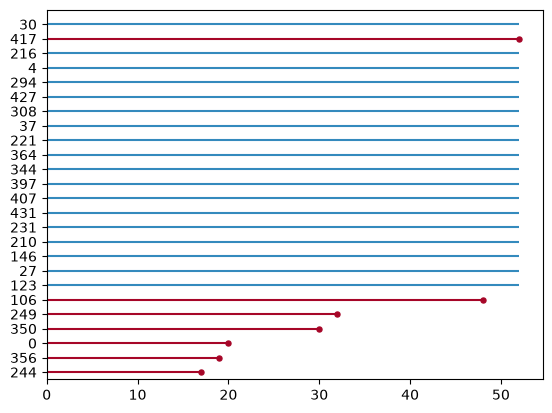

In [6]:
plot_lifetimes(df2["week"], df2["arrest"])

<Axes: xlabel='fin', ylabel='week'>

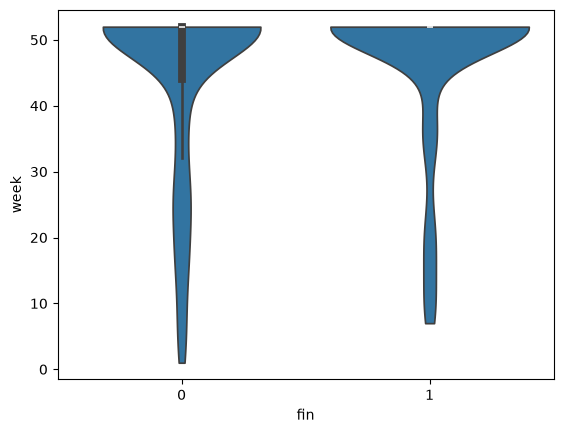

In [8]:
sns.violinplot(x="fin", y="week", data=df, cut=0)

<Axes: xlabel='fin', ylabel='week'>

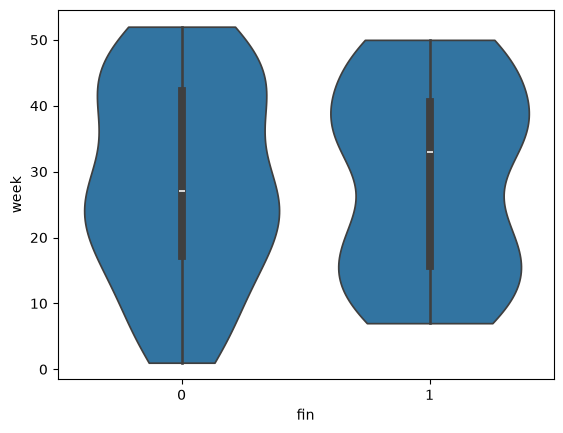

In [9]:
sns.violinplot(x="fin", y="week", data=df[df["arrest"] == 1], cut=0)

1.0 44.854166666666664


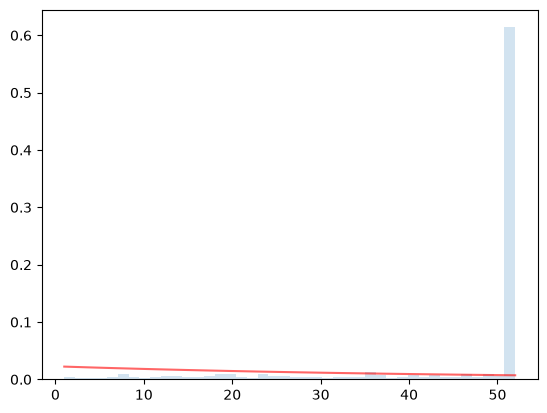

In [28]:
loc, scale = stats.expon.fit(df["week"])
RV = stats.expon(loc, scale)
print(loc, scale)

x = np.linspace(df["week"].min(), df["week"].max(), 100)
plt.plot(x, RV.pdf(x), "r-", alpha=0.6)
plt.hist(df["week"], density=True, bins="auto", histtype="stepfilled", alpha=0.2)
plt.show()

That didn't work... What excluding non-observed?

1.0 27.710526315789473


(array([0.00963192, 0.01788786, 0.02751978, 0.01926385, 0.0123839 ,
        0.0247678 , 0.01926385, 0.02614379]),
 array([ 1.   ,  7.375, 13.75 , 20.125, 26.5  , 32.875, 39.25 , 45.625,
        52.   ]),
 [<matplotlib.patches.Polygon at 0x7fdbef007b60>])

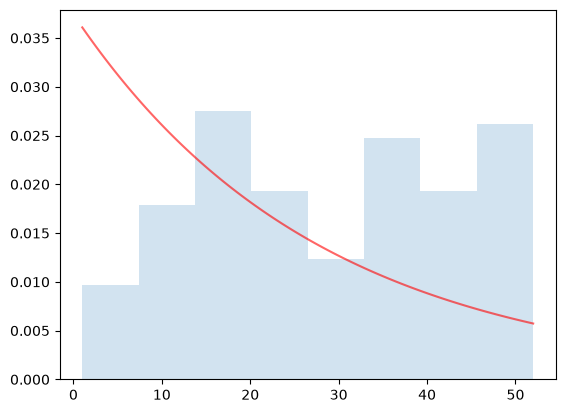

In [19]:
observed = df[df["arrest"] == 1]

loc, scale = stats.expon.fit(observed["week"])
RV = stats.expon(loc, scale)
print(loc, scale)

x = np.linspace(df["week"].min(), df["week"].max(), 100)
plt.plot(x, RV.pdf(x), "r-", alpha=0.6)
plt.hist(observed["week"], density=True, bins="auto", histtype="stepfilled", alpha=0.2)

2.0466744090629545 0 32.24412036259996


(array([0.00963192, 0.01788786, 0.02751978, 0.01926385, 0.0123839 ,
        0.0247678 , 0.01926385, 0.02614379]),
 array([ 1.   ,  7.375, 13.75 , 20.125, 26.5  , 32.875, 39.25 , 45.625,
        52.   ]),
 [<matplotlib.patches.Polygon at 0x7fdbf0107d90>])

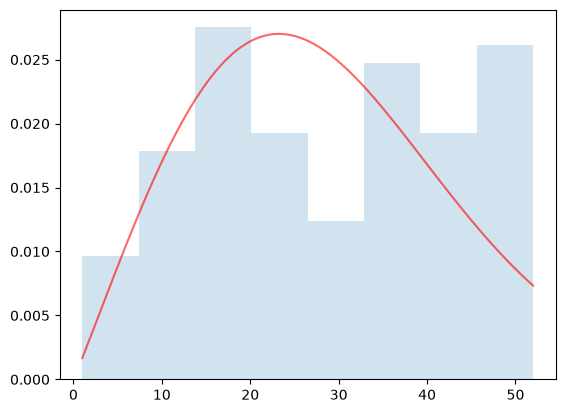

In [20]:
params = stats.weibull_min.fit(observed["week"], floc=0)
RV = stats.weibull_min(*params)
print(*params)

x = np.linspace(df["week"].min(), df["week"].max(), 100)
plt.plot(x, RV.pdf(x), "r-", alpha=0.6)
plt.hist(observed["week"], density=True, bins="auto", histtype="stepfilled", alpha=0.2)

AI,

* Look at these plots trying to fit an exponential and weibull distributions to my `rossi` dataset (only for observed arrested individuals).
* Obviously neither don't fit. Why? What can be done?
* What about our censored data? Rembmer that only once 52 weeks pass they are not longer tracked and hence "censored out"

Ignoring the censored data (using $1 - \mathrm{CDF}\left(t\right)$):

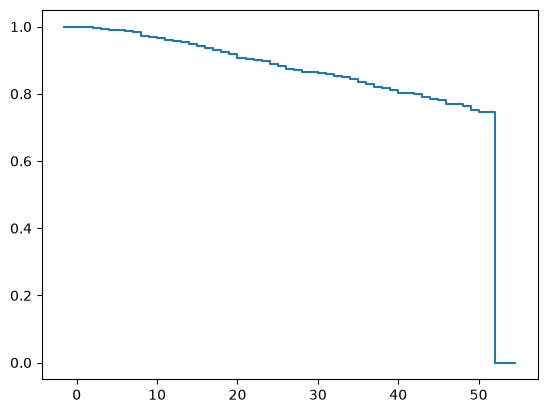

In [95]:
ecdf = stats.ecdf(df["week"])
ecdf.sf.plot()

<Axes: xlabel='timeline'>

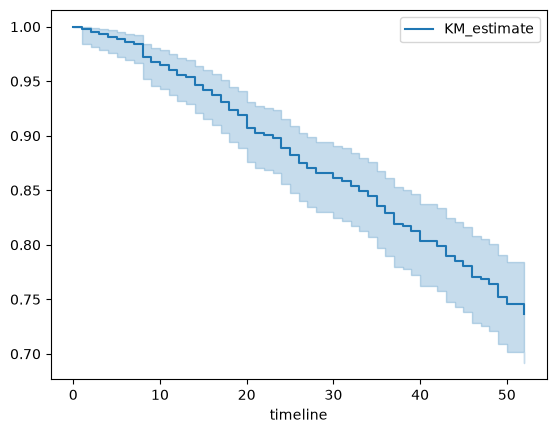

In [96]:
kmf = KaplanMeierFitter()
kmf.fit(durations=df["week"], event_observed=df["arrest"])
kmf.plot_survival_function()

$$
\hat{S}(t) = \prod_{i: t_i\le t} \left(1 - \frac{d_{i}}{q_{i}}\right)
$$

Hazard?

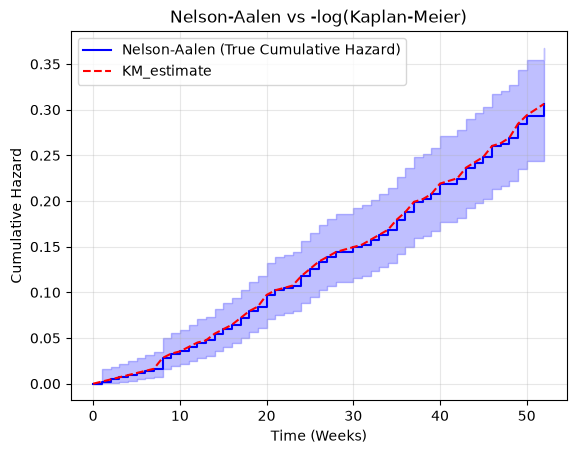

In [97]:
naf = NelsonAalenFitter()
naf.fit(durations=df["week"], event_observed=df["arrest"])

ax = naf.plot_cumulative_hazard(
    label="Nelson-Aalen (True Cumulative Hazard)", color="blue"
)

neg_log_km = -np.log(kmf.survival_function_)

# 4. Overlay -log(KM) on the same axes
neg_log_km.plot(
    ax=ax, label="-log(Kaplan-Meier) (Overestimation)", color="red", linestyle="--"
)

# 5. Format the plot
plt.title("Nelson-Aalen vs -log(Kaplan-Meier)")
plt.ylabel("Cumulative Hazard")
plt.xlabel("Time (Weeks)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

$$
\tilde{H}(t) = \sum_{t_i \le t} \frac{d_i}{q_i}
$$

AI,

* Does lifeline plot the Nelson-Aalen CI in the same method KM does? i.e. Greenwood's formula(-ish), log(-log), delta method?

Other factors?

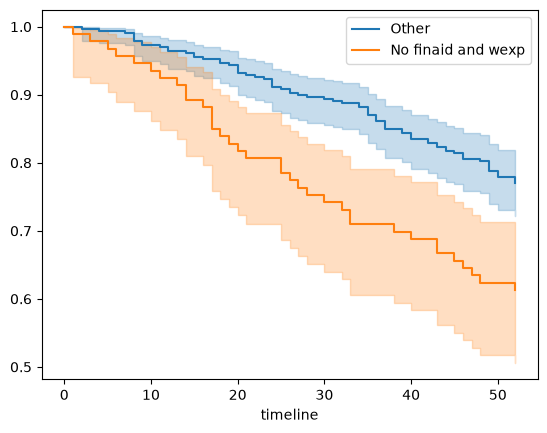

In [98]:
filter = (df["fin"] == 0) & (df["wexp"] == 0)

kmf1 = KaplanMeierFitter().fit(
    df[~filter]["week"], df[~filter]["arrest"], label="Other"
)
kmf2 = KaplanMeierFitter().fit(
    df[filter]["week"], df[filter]["arrest"], label="No finaid and wexp"
)

ax = kmf1.plot_survival_function()
ax = kmf2.plot_survival_function(ax=ax)

AI,

* My KM plot shows that the group who didn't recieve financial aid and had work experience are with a higher hazard rate
* What about ones who only had one of these? If I plot each group (in this case 4) seperately we'll eventually have much less data points
* Mention the next steps to check that there is indeed a significant drop, and how to truly measure the difference

group
fin=0_wexp=0     93
fin=0_wexp=1    123
fin=1_wexp=0     92
fin=1_wexp=1    124
dtype: int64


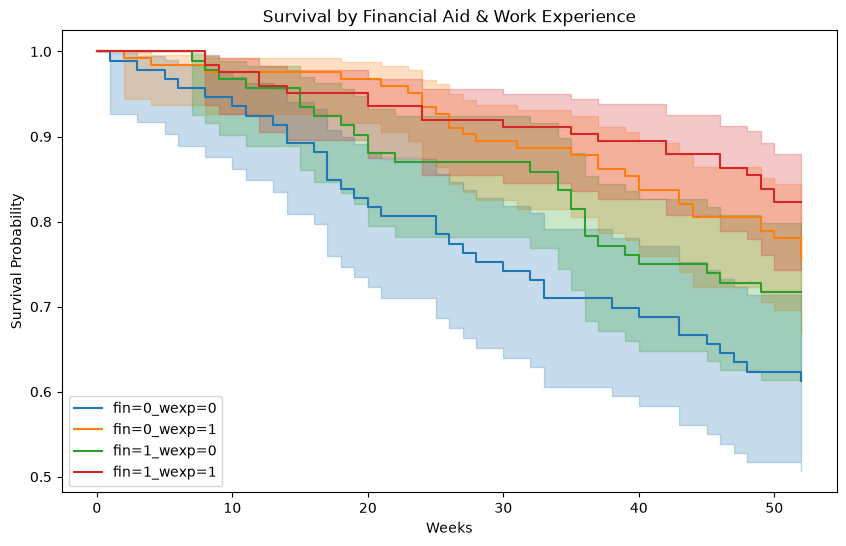

In [99]:
# Create the 4 groups
df["group"] = df.apply(lambda x: f"fin={int(x['fin'])}_wexp={int(x['wexp'])}", axis=1)

# Check group sizes
print(df.groupby("group").size())

fig, ax = plt.subplots(figsize=(10, 6))

groups = df.groupby("group")
for name, group in groups:
    kmf = KaplanMeierFitter()
    kmf.fit(group["week"], event_observed=group["arrest"], label=name)
    kmf.plot_survival_function(ax=ax, ci_show=True)

plt.title("Survival by Financial Aid & Work Experience")
plt.ylabel("Survival Probability")
plt.xlabel("Weeks")
plt.legend()
plt.show()

In [100]:
group_names = df["group"].unique()
for i, g1 in enumerate(group_names):
    for g2 in group_names[i + 1 :]:
        mask1 = df["group"] == g1
        mask2 = df["group"] == g2

        ps = []
        results = logrank_test(
            df.loc[mask1, "week"],
            df.loc[mask2, "week"],
            event_observed_A=df.loc[mask1, "arrest"],
            event_observed_B=df.loc[mask2, "arrest"],
        )
        ps.append(results.p_value)
        print(f"{g1} vs {g2}: p-value = {results.p_value:.4f}")

# Correction
stats.false_discovery_control(ps)

fin=0_wexp=0 vs fin=0_wexp=1: p-value = 0.0114
fin=0_wexp=0 vs fin=1_wexp=1: p-value = 0.0003
fin=0_wexp=0 vs fin=1_wexp=0: p-value = 0.1120
fin=0_wexp=1 vs fin=1_wexp=1: p-value = 0.2157
fin=0_wexp=1 vs fin=1_wexp=0: p-value = 0.4231
fin=1_wexp=1 vs fin=1_wexp=0: p-value = 0.0546


array([0.05457767])

Age? Prio?

AI,
* My dataset also contains non-binary data such as age (rounded) and prior convictions
* How can I take it into account without making each number a different group?

In [101]:
cph = CoxPHFitter()

cph.fit(df, duration_col="week", event_col="arrest", formula="fin + wexp + age + prio")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -660.28
         time fit was run = 2026-09-14 13:50:07 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.35      0.70      0.19           -0.72            0.02                0.49                1.02
wexp      -0.22      0.80      0.21           -0.63            0.19                0.53                1.20
age       -0.06      0.94      0.02           -0.10           -0.02                0.90                0.98
prio       0.09      1.09      0.03            0.03            0.14                1.03                1.16

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.84   0.07      3.92
wexp         0.00 -1.07   0.29      1.81
age          0.00 -2.69   0.01      7.13
prio         0.00  3.14 <0.005      9.20
---
Concordance = 0.64
Partial AIC = 1328.57
log-likelihood ratio test = 30.19 on 4 df
-log2(p) of ll-ratio test = 17.77

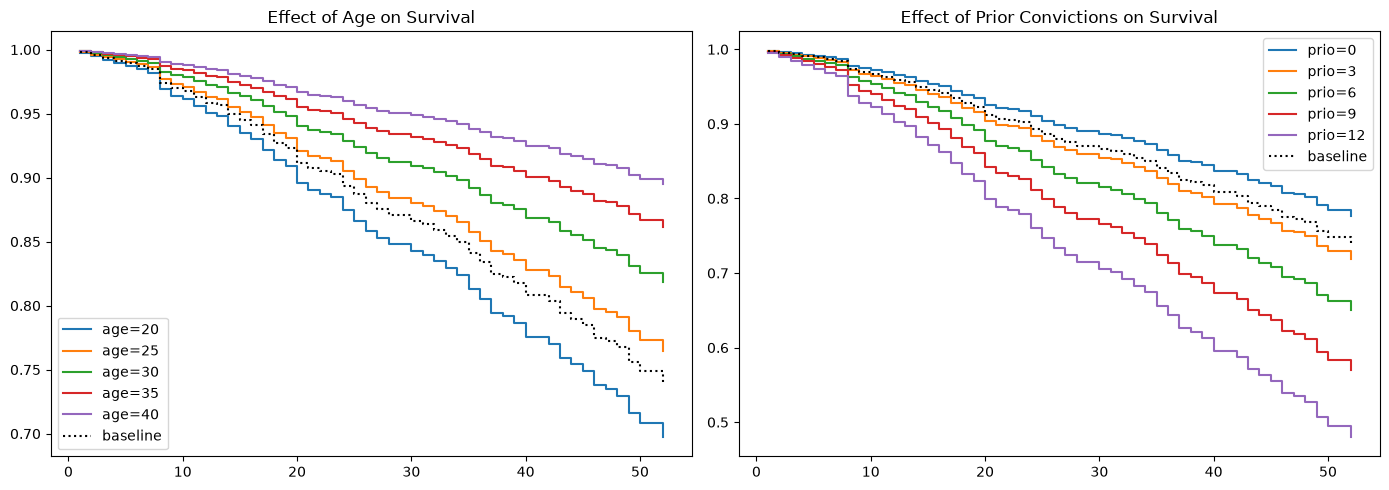

In [102]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the effect of Age (holding other variables at their mean)
cph.plot_partial_effects_on_outcome(
    covariates="age",
    values=[20, 25, 30, 35, 40],  # Pick 5 representative ages
    plot_baseline=True,
    ax=axes[0],
)
axes[0].set_title("Effect of Age on Survival")

# Plot the effect of Prior Convictions
cph.plot_partial_effects_on_outcome(
    covariates="prio",
    values=[0, 3, 6, 9, 12],  # Pick 5 representative prior counts
    plot_baseline=True,
    ax=axes[1],
)
axes[1].set_title("Effect of Prior Convictions on Survival")

plt.tight_layout()
plt.show()


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
         test_name = proportional_hazard_test

---
           test_statistic      p  -log2(p)
age  km             11.22 <0.005     10.27
     rank           11.58 <0.005     10.55
fin  km              0.00   0.95      0.07
     rank            0.00   0.97      0.05
prio km              0.01   0.94      0.09
     rank            0.00   0.96      0.06
wexp km              9.15 <0.005      8.65
     rank            9.05 <0.005      8.57



1. Variable 'wexp' failed the non-proportional test: p-value is 0.0025.

   Advice: with so few unique values (only 2), you can include `strata=['wexp', ...]` in the call in
`.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


2. Variable 'age' failed the non-proportional test: p-value is 0.0007.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/l

[[<Axes: xlabel='rank-transformed time\n(p=0.9674)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9545)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0026)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0025)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0007)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0008)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9584)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9424)'>]]

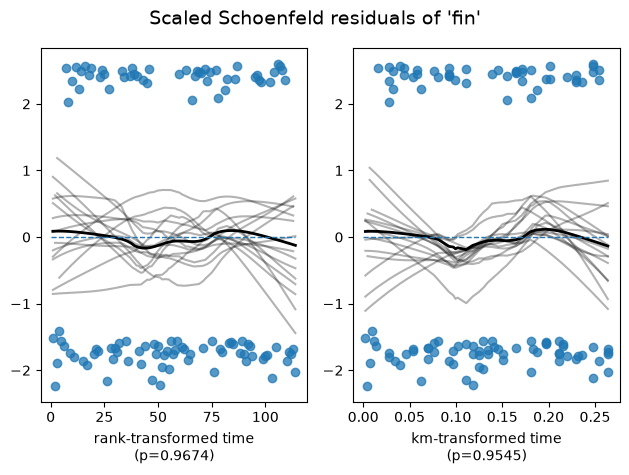

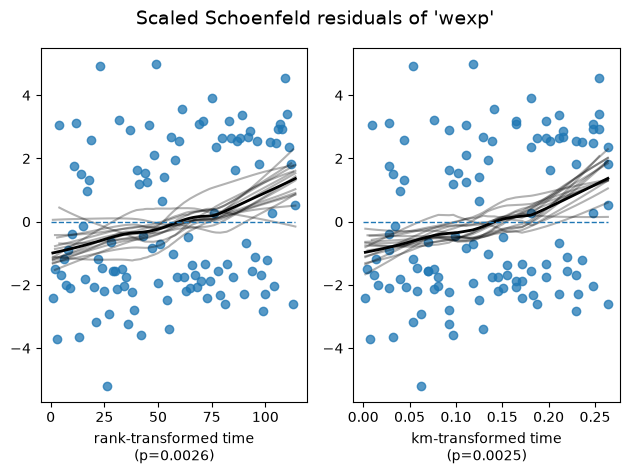

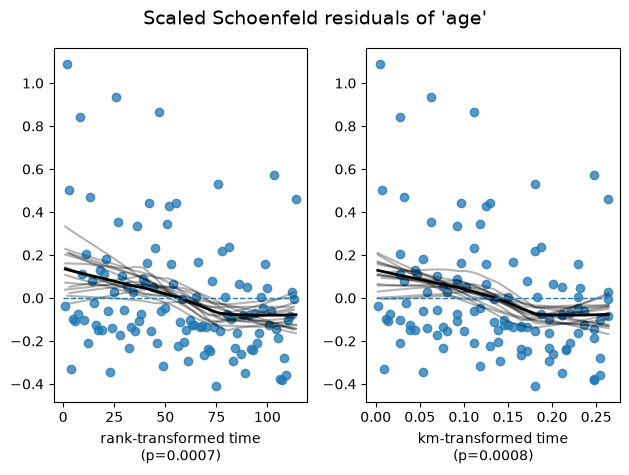

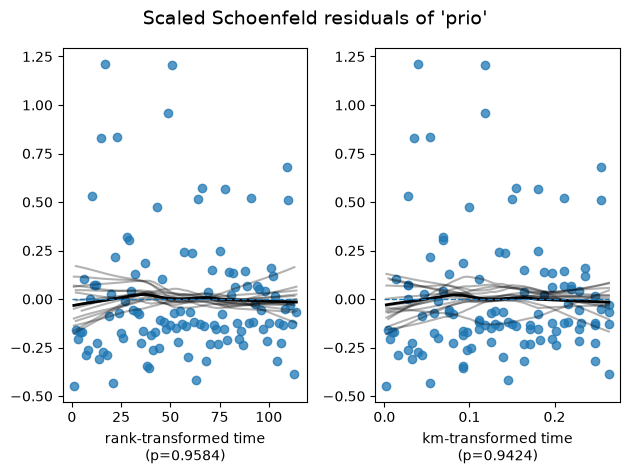

In [103]:
cph.check_assumptions(df, show_plots=True)

AI,

* Analyze this output for the assumptions. What are the conclusions?
* Where can we go from here?

[27 18 19 23 24 25 21 22 20 26 40 17 37 44 29 28 33 42 32 36 35 30 43 39
 38 34 31 41]


age_group
up to 25    302
24-30        91
31-35        25
35+          14
Name: count, dtype: int64

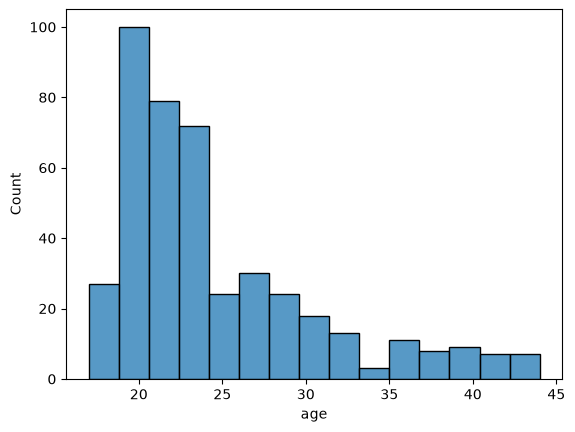

In [ ]:
print(pd.unique(df["age"]))

sns.histplot(df["age"])

bins = [0, 25, 35, 40, 100]

labels = ["up to 25", "26-30", "31-35", "35+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

df["age_group"].value_counts()

In [ ]:
cph = CoxPHFitter()
cph.fit(
    df,
    duration_col="week",
    event_col="arrest",
    formula="fin + prio",  # Only keep variables that passed the PH test
    strata=["wexp", "age_group"],  # Stratify on the ones that failed
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 432 total observations, 318 right-censored observations>
             duration col = 'week'
                event col = 'arrest'
                   strata = ['wexp', 'age_group']
      baseline estimation = breslow
   number of observations = 432
number of events observed = 114
   partial log-likelihood = -511.38
         time fit was run = 2026-09-14 13:50:08 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
fin       -0.38      0.69      0.19           -0.75           -0.00                0.47                1.00
prio       0.08      1.08      0.03            0.03            0.13                1.03                1.14

           cmp to     z      p  -log2(p)
covariate                               
fin          0.00 -1.97   0.05      4.37
prio         0.00  2.89 <0.005      8.03
---
Concordance = 0.57
Partial AIC = 1026.77
log-likelihood ratio test = 11.08 on 2 df
-log2(p) of ll-ratio test = 7.99

AI,

* What does stratification actually does? Give a mathematical explaination
* Despite stratifying and grouping my failed variables, the concordance score went down. What gives?